## **Northeastern SMILE Lab - Recognizing Faces in the Wild**

## Background

The SMILE Lab at Northeastern focuses on the frontier research of applied machine learning, social media analytics, human-computer interaction, and high-level image and video understanding. Their research is driven by the explosion of diverse multimedia from the Internet, including both personal and publicly available photos and videos. They start by treating fundamental theory from learning algorithms as the soul of machine intelligence and arm it with visual perception.

Northeastern University has been developing an automatic kinship classifier since 2010. However, the widespread adoption of this technology has been hindered by two primary factors:

- Data Limitations: Existing image databases for kinship recognition are insufficient in size and diversity to accurately represent global familial relationships.

- Model Complexity: The complex interplay of genetic and environmental factors influencing facial features necessitates a more advanced model than traditional computer vision algorithms, which are typically designed for higher-level tasks like facial recognition or object classification.

## Objective

Using the provided competition data, the following model predicts the probability of two individuals being related (1) based solely on a pair of facial images. 

## **Step 1**: Download the official Kaggle competition (FIW) data.

***Before executing the following cells***, please review section 7 of the rules: https://www.kaggle.com/competitions/recognizing-faces-in-the-wild/rules#7-competition-data. 

Note that all usages of FIW data should cite the following papers:

*Joseph P Robinson, Ming Shao, Hongfu Liu, Yue Wu, Timothy Gillis, and Yun Fu. "Visual Kinship Recognition of Families In the Wild" IEEE TPAMI Special Edition: Computational Face (2018).
Joseph P Robinson, Ming Shao, Handong Zhao, Yue Wu, Timothy Gillis, Yun Fu. "Recognizing Families In the Wild (RFIW): Data Challenge Workshop in conjunction with ACM MM 2017," ACM Multimedia Conference: Workshop on RFIW (2017).
Shuyang Wang, Joseph P Robinson, and Yun Fu. “Kinship Verification on Families in the Wild with Marginalized Denoising Metric Learning,” in IEEE Automatic Face and Gesture Recognition (2017).
Joseph P Robinson, Ming Shao, Yue Wu, and Yun Fu. “Families In the Wild (FIW): large-scale kinship image database and benchmarks." in ACM on Multimedia Conference (2016).*

In [1]:
download_path = '_provided-data' # Intermediate directories are excluded recursively via. .gitignore (i.e., '_*/').
competition = 'recognizing-faces-in-the-wild' # Hosted here: https://www.kaggle.com/c/recognizing-faces-in-the-wild


In [ ]:
import os
from kaggle.api.kaggle_api_extended import KaggleApi

zip_path = download_path + '/' + competition + '.zip'
if os.path.exists(zip_path):
    print('Data already downloaded: ' + zip_path)
else:
    os.makedirs(download_path, exist_ok=True)
    print('Downloading ' + competition + ' provided data into ' + download_path)
    api = KaggleApi()
    api.authenticate()
    api.competition_download_files(competition, path = download_path)

In [3]:
import os
import zipfile

def unzip(zip_path):
    dest_dir = '_' + os.path.basename(zip_path)[:-4]
    if (not os.path.exists(dest_dir)):
        os.makedirs(dest_dir, exist_ok=True)
        print('Decompressing ' + zip_path + ' into ' + dest_dir)
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(dest_dir)
    print(dest_dir + '/')
    print(os.listdir(dest_dir)[:10])
    return dest_dir

print('Decompressing ' + competition + ' provided data:')
dataset_path = unzip(download_path + '/' + competition + '.zip')
training_image_path = unzip(dataset_path + '/train-faces.zip')
testing_image_path = unzip(dataset_path + '/test-faces.zip')


Decompressing recognizing-faces-in-the-wild provided data:
_recognizing-faces-in-the-wild/
['sample_submission.csv', 'test-faces.zip', 'train_relationships.csv', 'test-private-faces.zip', 'test.zip', 'train.zip', 'test-private-lists.zip', 'README.md', 'test-private-labels.zip', 'test-public-lists.zip']
_train-faces/
['F0215', 'F0938', 'F0879', 'F0343', 'F0942', 'F0399', 'F0880', 'F0596', 'F0982', 'F0617']
_test-faces/
['SZZABP43WT.jpg', 'Z33WEH4PZK.jpg', 'F3FRRAUTML.jpg', 'EGHKJO6NCT.jpg', 'ODVXNXN6W3.jpg', 'GG7LSRIQ3H.jpg', 'P4ZV7KH3HU.jpg', 'V66Y7ETYO5.jpg', '4W2ECBKR7L.jpg', 'FZCM7UW4BD.jpg']


## **Step 2**: Load and clean the labeled dataset.
The _train_relationships.csv_ encodes (ground truth) kinship relations between pairs of people. 


In [4]:
from collections import defaultdict
import glob
import pandas

relations_csv_path = dataset_path + '/train_relationships.csv'
print('Loading ' + relations_csv_path)
relations_df = pandas.read_csv(relations_csv_path, delimiter=',', header='infer')

# Create a dictionary to lookup image files for each member
family_dict = defaultdict(list)
for family in glob.glob(training_image_path + '*'):
    for member in glob.glob(family + '/*'):
        for image_path in glob.glob(member + '/*'):
            member = os.path.basename(member)
            image_path = os.path.basename(image_path)
            family_dict[member].append(image_path)

print('Images found for members of ' + str(len(family_dict.items())) + ' total families.')
for key, value in list(family_dict.items())[:5]:
    print(str(key) + ': ' + str(value) + ',')
    
# Remove entries which do not exist in the training set
print('The original ground truth relations data contains ' + str(len(relations_df)) + ' pairs.')
print(relations_df)

print('Checking for missing relation image data.')
fam_keys = family_dict.keys()
missing_relations_list = []
for index, row in relations_df.iterrows():
    split1 = row.p1.split('/')
    split2 = row.p2.split('/')
    p1fam = split1[0]
    p2fam = split2[0]
    if (p1fam not in fam_keys or p2fam not in fam_keys):
        missing_relations_list.append(index)
        continue
    p1member = split1[1]
    p2member = split2[1]
    if (p1member not in family_dict[p1fam] or p2member not in family_dict[p2fam]):
        missing_relations_list.append(index)
        continue
    images1 = os.listdir(training_image_path + '/' + p1fam + '/' + p1member)
    images2 = os.listdir(training_image_path + '/' + p2fam + '/' + p2member)
    if (len(images1) == 0 or len(images2) == 0):
        missing_relations_list.append(index)
        continue
if missing_relations_list:
    relations_df = relations_df.drop(missing_relations_list)
    print(str(len(missing_relations_list)) + ' pairs were removed due to missing data.')
    print(relations_df)
else:
    print('All relations were found to have valid image data.')

Loading _recognizing-faces-in-the-wild/train_relationships.csv
Images found for members of 786 total families.
F0215: ['MID6', 'MID3', 'MID8', 'MID5', 'MID1', 'MID9', 'MID2'],
F0938: ['MID4', 'MID3', 'MID5', 'MID1', 'MID2'],
F0879: ['MID6', 'MID4', 'MID3', 'MID5', 'MID1', 'MID2'],
F0343: ['MID4', 'MID3', 'MID1', 'MID2'],
F0942: ['MID4', 'MID3', 'MID1', 'MID2'],
The original ground truth relations data contains 3598 pairs.
              p1          p2
0     F0002/MID1  F0002/MID3
1     F0002/MID2  F0002/MID3
2     F0005/MID1  F0005/MID2
3     F0005/MID3  F0005/MID2
4     F0009/MID1  F0009/MID4
...          ...         ...
3593  F1000/MID5  F1000/MID8
3594  F1000/MID5  F1000/MID9
3595  F1000/MID6  F1000/MID9
3596  F1000/MID7  F1000/MID8
3597  F1000/MID7  F1000/MID9

[3598 rows x 2 columns]
Checking for missing relation image data.
1108 pairs were removed due to missing data.
              p1          p2
0     F0002/MID1  F0002/MID3
1     F0002/MID2  F0002/MID3
2     F0005/MID1  F0005/MID

## **Step 3**: Show a random selection of the relations.

              p1          p2
390   F0123/MID6  F0123/MID7
2197  F0639/MID5  F0639/MID7
1710  F0494/MID1  F0494/MID3


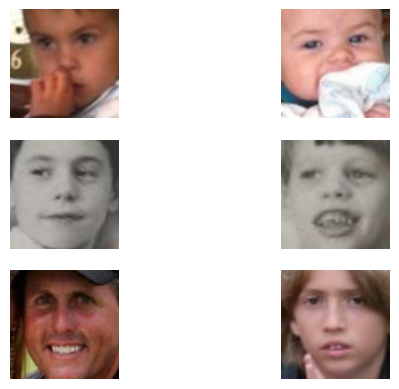

In [5]:
from PIL import Image
import matplotlib.pyplot as plt
from random import choice

SAMPLE_COUNT = 3
samples = relations_df.sample(SAMPLE_COUNT)
print(samples)

f, ax = plt.subplots(SAMPLE_COUNT, 2)
for a in ax.flat:
    a.axis('off')
i = 0
for member in samples.values:
    img1 = training_image_path + '/' + member[0] + '/' \
        + choice(os.listdir(training_image_path + '/' + member[0]))
    img2 = training_image_path + '/' + member[1] + '/'  \
        + choice(os.listdir(training_image_path + '/' + member[1]))
    rgb1 = Image.open(img1)
    rgb2 = Image.open(img2)
    ax[i][0].imshow(rgb1)
    ax[i][1].imshow(rgb2)
    i = i + 1


## **Step 4**: Split by family and generate training, validation, and test pairs.

In [7]:
import itertools
import random
import numpy
import torch

random.seed(42)
numpy.random.seed(42)
torch.manual_seed(42)

# Extract unique family IDs and split 70/15/15
all_families = sorted(set(row.p1.split('/')[0] for _, row in relations_df.iterrows()))
random.shuffle(all_families)
n = len(all_families)
train_cutoff = int(0.70 * n)
val_cutoff = int(0.85 * n)
train_families = set(all_families[:train_cutoff])
val_families = set(all_families[train_cutoff:val_cutoff])
test_families = set(all_families[val_cutoff:])
print(f'Family split: {len(train_families)} train, {len(val_families)} val, {len(test_families)} test')

# Build member image lookup from all members in relations_df
members = sorted(set(m for row in relations_df.values for m in row))
member_images = dict()
for member in members:
    image_files = os.listdir(training_image_path + '/' + member)
    if len(image_files) > 0:
        member_images[member] = [member + '/' + img for img in image_files]

def generate_pairs(relations_subset, family_set):
    """Generate balanced positive and negative pairs for a family split."""
    # Positive pairs: all image combinations for each related pair
    positives = []
    for _, row in relations_subset.iterrows():
        p1_images = member_images.get(row.p1, [])
        p2_images = member_images.get(row.p2, [])
        for img1, img2 in itertools.product(p1_images, p2_images):
            positives.append([img1, img2, 1.0])

    # Negative pairs: sample unrelated members within the same family set
    split_members = [m for m in members if m.split('/')[0] in family_set and m in member_images]
    negatives = []
    while len(negatives) < len(positives):
        p1 = random.choice(split_members)
        p2 = random.choice(split_members)
        if p1 == p2:
            continue
        p1_images = member_images[p1]
        p2_images = member_images[p2]
        for img1, img2 in itertools.product(p1_images, p2_images):
            negatives.append([img1, img2, 0.0])
            if len(negatives) >= len(positives):
                break

    data = positives + negatives[:len(positives)]
    random.shuffle(data)
    return data, len(positives), len(negatives[:len(positives)])

# Split relations by family
train_relations = relations_df[relations_df['p1'].apply(lambda x: x.split('/')[0] in train_families)]
val_relations = relations_df[relations_df['p1'].apply(lambda x: x.split('/')[0] in val_families)]
test_relations = relations_df[relations_df['p1'].apply(lambda x: x.split('/')[0] in test_families)]

training_data, train_pos, train_neg = generate_pairs(train_relations, train_families)
val_data, val_pos, val_neg = generate_pairs(val_relations, val_families)
testing_data, test_pos, test_neg = generate_pairs(test_relations, test_families)

print(f'Training:   {len(training_data)} pairs ({train_pos} pos + {train_neg} neg)')
print(f'Validation: {len(val_data)} pairs ({val_pos} pos + {val_neg} neg)')
print(f'Testing:    {len(testing_data)} pairs ({test_pos} pos + {test_neg} neg)')

Family split: 249 train, 53 val, 54 test
Training:   216018 pairs (108009 pos + 108009 neg)
Validation: 17362 pairs (8681 pos + 8681 neg)
Testing:    23776 pairs (11888 pos + 11888 neg)


## **Step 5**: Train the model

In [ ]:
import torch
from torch.utils.data import Dataset
import torchvision.transforms as transforms
from PIL import Image

# Training transform with data augmentation (#8)
train_transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# Evaluation transform without random augmentations (#8)
eval_transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

class ImagePairDataset(Dataset):
    def __init__(self, data, transform):
        self.image_pairs = [sublist[:-1] for sublist in data]
        self.labels = torch.tensor([sublist[-1] for sublist in data], dtype=torch.float32)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img0 = Image.open('_train-faces/' + self.image_pairs[idx][0])
        img1 = Image.open('_train-faces/' + self.image_pairs[idx][1])
        img0 = self.transform(img0)
        img1 = self.transform(img1)
        return img0, img1, self.labels[idx]

batch_size = 64

train_dataset = ImagePairDataset(training_data, train_transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
print(f'Train: {len(train_dataset)} samples, {len(train_loader)} batches')

val_dataset = ImagePairDataset(val_data, eval_transform)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
print(f'Val:   {len(val_dataset)} samples, {len(val_loader)} batches')

test_dataset = ImagePairDataset(testing_data, eval_transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
print(f'Test:  {len(test_dataset)} samples, {len(test_loader)} batches')

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from facenet_pytorch import InceptionResnetV1

class SiameseNetwork(nn.Module):
    def __init__(self):
        super(SiameseNetwork, self).__init__()

        # Pretrained FaceNet backbone (#7)
        backbone = InceptionResnetV1(pretrained='vggface2')

        # Freeze all layers
        for param in backbone.parameters():
            param.requires_grad = False

        # Unfreeze last 2 blocks (repeat_3 and block8)
        for name, param in backbone.named_parameters():
            if name.startswith('repeat_3.') or name.startswith('block8.'):
                param.requires_grad = True

        # Use backbone up through avgpool (strip the classification head)
        self.backbone = nn.Sequential(
            backbone.conv2d_1a,
            backbone.conv2d_2a,
            backbone.conv2d_2b,
            backbone.maxpool_3a,
            backbone.conv2d_3b,
            backbone.conv2d_4a,
            backbone.conv2d_4b,
            backbone.repeat_1,
            backbone.mixed_6a,
            backbone.repeat_2,
            backbone.mixed_7a,
            backbone.repeat_3,
            backbone.block8,
            backbone.avgpool_1a,
            nn.Flatten(),
            backbone.dropout,
            backbone.last_linear,
            backbone.last_bn,
        )

        # FC head: 512 → 128 embedding
        self.fc1 = nn.Linear(512, 128)

    def forward_once(self, x):
        output = self.backbone(x)
        output = self.fc1(output)
        return output

    def forward(self, input1, input2):
        output1 = self.forward_once(input1)
        output2 = self.forward_once(input2)
        return output1, output2

class ContrastiveLoss(torch.nn.Module):
    def __init__(self, margin=2.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        euclidean_distance = F.pairwise_distance(output1, output2, keepdim = True)
        # label=1 means related (similar) → minimize distance
        # label=0 means unrelated (dissimilar) → push distance beyond margin
        loss_contrastive = torch.mean((label) * torch.pow(euclidean_distance, 2) +
                                      (1-label) * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2))
        return loss_contrastive

# Hyperparameters (reduced epochs — pretrained backbone converges faster)
num_epochs = 10
learning_rate = 0.0001
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create the network
model = SiameseNetwork()
criterion = ContrastiveLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)

In [ ]:
def train(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for i, (data1, data2, label) in enumerate(dataloader):
        data1, data2, label = data1.to(device), data2.to(device), label.to(device)
        optimizer.zero_grad()
        output1, output2 = model(data1, data2)
        loss = criterion(output1, output2, label)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * data1.size(0)

    return running_loss / len(dataloader.dataset)

def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for data1, data2, label in dataloader:
            data1, data2, label = data1.to(device), data2.to(device), label.to(device)
            output1, output2 = model(data1, data2)
            loss = criterion(output1, output2, label)
            running_loss += loss.item() * data1.size(0)
    return running_loss / len(dataloader.dataset)

for epoch in range(num_epochs):
    train_loss = train(model, train_loader, criterion, optimizer, device)
    val_loss = validate(model, val_loader, criterion, device)
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:3d}/{num_epochs} — Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

print('Finished training.')

In [ ]:
# Sanity check: verify related pairs have smaller distances than unrelated pairs
model.eval()
pos_distances = []
neg_distances = []

with torch.no_grad():
    for data1, data2, label in train_loader:
        data1, data2, label = data1.to(device), data2.to(device), label.to(device)
        output1, output2 = model(data1, data2)
        distances = F.pairwise_distance(output1, output2)
        for d, l in zip(distances, label):
            if l.item() == 1.0:
                pos_distances.append(d.item())
            else:
                neg_distances.append(d.item())

mean_pos = sum(pos_distances) / len(pos_distances)
mean_neg = sum(neg_distances) / len(neg_distances)
print(f'Mean distance (related pairs):   {mean_pos:.4f}')
print(f'Mean distance (unrelated pairs): {mean_neg:.4f}')
if mean_pos < mean_neg:
    print('PASS: Related pairs are closer than unrelated pairs.')
else:
    print('FAIL: Related pairs are NOT closer. The model may not be learning meaningful representations.')

In [10]:
# Optionally store the (trained) model to file.
torch.save(model.state_dict(),'_model-state-dict.pth')


## **Step 6**: Test the model

In [11]:
# Optionally load the (trained) model from file.
model.load_state_dict(torch.load('_model-state-dict.pth'))

C:\Users\jplumb\AppData\Local\Temp\ipykernel_5104\1730811235.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('_model-state-dict.pth'))


<All keys matched successfully>

In [ ]:
# Test DataLoader is already created in the dataset setup cell (test_loader).
# Proceeding directly to evaluation.

In [ ]:
def test(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_distances = []
    all_labels = []

    with torch.no_grad():
        for i, (data1, data2, label) in enumerate(dataloader):
            data1, data2, label = data1.to(device), data2.to(device), label.to(device)

            output1, output2 = model(data1, data2)
            loss = criterion(output1, output2, label)
            running_loss += loss.item() * data1.size(0)

            distances = F.pairwise_distance(output1, output2)
            all_distances.extend(distances.cpu().numpy())
            all_labels.extend(label.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    print(f'Test Loss: {epoch_loss:.4f}')
    return all_distances, all_labels

test_distances, test_labels = test(model, test_loader, criterion, device)

In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score

distances = np.array(test_distances)
labels = np.array(test_labels)

# Convert distances to similarity scores (lower distance = higher similarity)
scores = 1 - (distances / distances.max())

# AUC-ROC
auc = roc_auc_score(labels, scores)
print(f'AUC-ROC: {auc:.4f}')

# ROC curve
fpr, tpr, thresholds = roc_curve(labels, scores)

# Optimal threshold via Youden's J statistic
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]
print(f'Optimal threshold (Youden\'s J): {optimal_threshold:.4f}')

# Classification metrics at optimal threshold
predictions = (scores >= optimal_threshold).astype(float)
acc = accuracy_score(labels, predictions)
prec = precision_score(labels, predictions)
rec = recall_score(labels, predictions)
print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')

# Plot ROC curve
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, label=f'ROC (AUC = {auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', zorder=5, label=f'Optimal ({optimal_threshold:.2f})')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# Distance distributions
pos_dist = distances[labels == 1.0]
neg_dist = distances[labels == 0.0]
axes[1].hist(pos_dist, bins=30, alpha=0.6, label=f'Related (n={len(pos_dist)})')
axes[1].hist(neg_dist, bins=30, alpha=0.6, label=f'Unrelated (n={len(neg_dist)})')
axes[1].set_xlabel('Euclidean Distance')
axes[1].set_ylabel('Count')
axes[1].set_title('Distance Distributions')
axes[1].legend()

plt.tight_layout()
plt.show()

## **Step 7**: Evaluation
Submissions are [evaluated](https://www.kaggle.com/competitions/recognizing-faces-in-the-wild/overview/evaluation) on area under the ROC curve between the predicted probability and the observed target. Not all pairs will be scored.

**Submission File**

For each img_pair in the test set, you must predict a probability for the is_related variable. The column img_pair describes the pair of images, i.e., abcdef-ghijkl means the pair of images abcdef.jpg and ghijkl.jpg.
The file should contain a header and have the following format:

```
img_pair,is_related
X3Nk6Hfe5x-qcZrTXsfde,0.0
X3Nk6Hfe5x-LD0pWDM8w_,0.0
X3Nk6Hfe5x-PHwuDtHyGp,0.0
X3Nk6Hfe5x-LO6lN_U4ot,0.0
...
```

In [ ]:

from PIL import Image
import itertools
import os

def pre_process(filename):
    img = Image.open(filename)
    img = eval_transform(img)
    img = img.unsqueeze(0)
    return img

# Create a lookup table of pre-processed test images (processed_image_tensors).
processed_image_tensors = {}
basenames = [os.path.splitext(file)[0] for file in os.listdir('_test-faces')]
for basename in basenames:
    processed_image_tensors[basename] = pre_process(testing_image_path + '/' + basename + '.jpg')
print('There are ' + str(len(processed_image_tensors)) + ' total entries in the lookup table.')

# Generate a list of all pairs of test images.
test_pairs = list(itertools.combinations(basenames, 2))
print('There are ' + str(len(test_pairs)) + ' total pairs in the test set.')


In [ ]:
import csv
import torch
import torch.nn.functional as F

def is_related(img1, img2, model):
    with torch.no_grad():
        output1, output2 = model(img1, img2)
    euclidean_distance = F.pairwise_distance(output1, output2, keepdim = True)
    probability = 1 - torch.sigmoid(euclidean_distance).item()
    return probability

filename = "submission.csv"
with open(filename, 'w', newline='') as file:
    csv_writer = csv.writer(file)
    csv_writer.writerows([['img_pair', 'is_related']])

# Evaluate the test image pairs
model.eval()  # Set model to evaluation mode
# Results are written in blocks to enable intermediate inspection.
i = 0
block_size = 10000
results_block = []
random.shuffle(test_pairs)
for pair in list(test_pairs):
    images = list(pair)
    results_block.append([images[0] + '-' + images[1],
                          format(is_related(processed_image_tensors[images[0]],
                                            processed_image_tensors[images[1]],
                                            model), '.6f'),
                          ])
    i = i + 1
    if (0 == i % block_size):
        with open(filename, 'a', newline='') as file:
            csv_writer = csv.writer(file)
            csv_writer.writerows(results_block)
        results_block = []

with open(filename, 'a', newline='') as file:
    csv_writer = csv.writer(file)
    csv_writer.writerows(results_block)